In [1]:
# Defining project paths
BASE_DIR = "D:/Capstone/capstone_repo"
DATA_DIR = f"{BASE_DIR}/data"
NB_DIR = f"{BASE_DIR}/notebooks"

import os
os.makedirs(DATA_DIR, exist_ok=True)

In [2]:
import networkx as nx
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from shapely.geometry import Point, mapping
from shapely import wkt
import unicodedata
from rapidfuzz import process, fuzz
import re
import rasterio
from rasterio.mask import mask

# Helper function: save as csv and gpkg files

In [3]:
def save_clean_data(df, gdf, filename):
    filepath = os.path.join(f"{DATA_DIR}/processed", filename)
    df.to_csv(filepath + ".csv", index=False)
    gdf.to_file(filepath + ".gpkg", layer="stops", driver="GPKG")

# Hospitals data

### Read data

In [4]:
hospitals = pd.read_csv(f"{DATA_DIR}/raw/casablanca_healthcare.csv")
hospitals.head()

,name,amenity,geometry,lat,lon
0,Clinique Badr مصحة بدر,clinic,POINT (-7.6410981 33.5948697),33.594870,-7.641098
1,clinique dentaire casablanca (cdc),clinic,POINT (-7.6482094 33.5874104),33.587410,-7.648209
2,Centre consultation et traitement dentaires,hospital,POINT (-7.6206013 33.5730773),33.573077,-7.620601
3,Clinique d'accouchement,clinic,POINT (-7.6240936 33.5930596),33.593060,-7.624094
4,Hôpital Sidi Othmane,hospital,POINT (-7.5733008 33.5585424),33.558542,-7.573301


### Basic Data Inspection

In [5]:
print("Healthcare dataset:", hospitals.shape)

Healthcare dataset: (102, 5)


In [6]:
hospitals.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      95 non-null     object 
 1   amenity   102 non-null    object 
 2   geometry  102 non-null    object 
 3   lat       102 non-null    float64
 4   lon       102 non-null    float64
dtypes: float64(2), object(3)
memory usage: 4.1+ KB


The dataframe contains 102 entries containing name, type of amenity, geometry, and latitude/longitude information about facilities. Information almost complet, only some names missing.

In [7]:
hospitals.describe()

,lat,lon
count,102.000000,102.000000
mean,33.574283,-7.608232
std,0.018247,0.045740
min,33.519839,-7.687311
25%,33.560484,-7.636317
50%,33.573942,-7.620545
75%,33.587749,-7.590609
max,33.612397,-7.483485


The latitude ranges from 33.5198 to 33.6124 (mean: 33.5743), and the longitude ranges from -7.6873 to -7.4835 (mean: -7.6082). The coordinates are fairly clustered around the mean, with standard deviations of 0.0182 for latitude and 0.0457 for longitude.

### Missing names/values

In [8]:
# Manually filling in missing names based on the original dataset and Google Maps to ensure accuracy. 
hospitals.loc[47, "name"] = "Clinique Al Oumouma"
hospitals.loc[71, "name"] = "HOPITAL UNIVERSITAIRE DE PROXIMITE"
hospitals.loc[80, "name"] = "Hôpital Municipal sidi moumen Tacharouk"
hospitals.loc[88, "name"] = "Centre de Maladies du Rein et de Dialyse AL AMINE"
hospitals.loc[97, "name"] = "Clinique Al Wafaa"
hospitals.loc[98, "name"] = "Centre de Santé Al Massira 2 (Niveau 2)"

### Filtering Non-Hospital Healthcare Facilities (Dental, Ophtalmo, etc.)

This code filters the hospital dataset to focus on general hospitals. It excludes entries related to dental, maternity, pharmacies, laboratories, and other specialized clinics by using a list of keywords. 
Remaining Rows with missing names are also removed as they can't be identified..

In [9]:
# List of keywords to exclude
keywords = [
    "dentaire", "accouchement", "maternité", "pharmacie",
    "labo", "kine", "kiné", "ophtal",
    "hemo", "cardio", "radio",
    "Al Oumouma", "Dialyse", "Pasteur"
]

# Create regex pattern
pattern = "|".join(keywords)

# Drop null names
hospitals = hospitals.dropna(subset=["name"])

# Filter rows
hospitals = hospitals[~hospitals["name"].str.contains(pattern, case=False, na=False)]

### Duplicated rows

In [10]:
# Check for duplicates in the 'name' column
hospitals[hospitals.duplicated(subset=["name"], keep=False)]

,name,amenity,geometry,lat,lon
7,Avicenne Clinique des Spécialistes ابن سينا,clinic,POINT (-7.6110661 33.5542874),33.554287,-7.611066
8,Avicenne Clinique des Spécialistes ابن سينا,clinic,POINT (-7.6109113 33.5543506),33.554351,-7.610911
54,Hopital 20 Aout,hospital,"POLYGON ((-7.6207405 33.5752817, -7.6206681 33...",33.575137,-7.621018
55,Hopital 20 Aout,hospital,"POLYGON ((-7.6217004 33.57581, -7.6183329 33.5...",33.574653,-7.619653


Manually checked the accuracy of the location of each duplicated hospital. Kept the one with the most accurate location

In [11]:
hospitals = hospitals.drop_duplicates(subset=["name"], keep="last")

### Handling Arabic chars

Rows where name is only in arabic

In [12]:
# Checking if some names have only arabic characters and spaces
pattern = r'^[\u0600-\u06FF\s]+$'

arabic_only_df = hospitals[hospitals["name"].str.match(pattern, na=False)]

In [13]:
arabic_only_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      0 non-null      object 
 1   amenity   0 non-null      object 
 2   geometry  0 non-null      object 
 3   lat       0 non-null      float64
 4   lon       0 non-null      float64
dtypes: float64(2), object(3)
memory usage: 0.0+ bytes


There no names with only arabic characters

Hospital names are cleaned to standardize the dataset. Arabic characters are removed to keep only the French/Latin part of names, which ensures consistency for filtering, grouping, and analysis.                                
All text is converted to lowercase and stripped from extra spaces.  

In [14]:
def clean_name(text):
    text = str(text).strip().lower()
    
    # Remove Arabic characters
    no_arabic = re.sub(r'[\u0600-\u06FF]+', '', text)
    no_arabic = re.sub(r'\s+', ' ', no_arabic).strip()
    
    # If something remains (French/Latin part exists)
    if no_arabic != "":
        return no_arabic
    else:
        # If it was fully Arabic, keep original (Already checked previously that there are none)
        return text

hospitals["name"] = hospitals["name"].apply(clean_name)

Renaming columns

In [15]:
# Renaming latitude and longitude columns for consistency with other datasets
hospitals = hospitals.rename(columns={
    "lat": "latitude",
    "lon": "longitude"
})

In [16]:
# Drop unnecessary columns
hospitals.drop(columns=["amenity", "geometry"], inplace=True)

In [17]:
hospitals.info()

<class 'pandas.core.frame.DataFrame'>
Index: 82 entries, 0 to 100
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   name       82 non-null     object 
 1   latitude   82 non-null     float64
 2   longitude  82 non-null     float64
dtypes: float64(2), object(1)
memory usage: 2.6+ KB


The dataste now contains no missing values

### Final processing by converting to GDF and saving the dataset

In [18]:
# Create geometry column from latitude and longitude
hospitals["geometry"] = hospitals.apply(
    lambda row: Point(row["longitude"], row["latitude"]),
    axis=1
)

# Create GeoDataFrame
healthcare_gdf = gpd.GeoDataFrame(
    hospitals,
    geometry="geometry",
    crs="EPSG:4326"
)

In [19]:
# Save the cleaned data
save_clean_data(hospitals, healthcare_gdf, "Casablanca_Healthcare")

# Public Transport: Collected via JSON API

Casablanca has two main transport systems: 
- CasaBus: the city's official bus system;
- Casatramway & Casabusway: that include a developed tram network and high-level bus network;


The datasets were collected using JSON API from companies official websites.


Each dataset is preprocessed seperately before merging them.

## CasaBus data

### Load Data

In [20]:
casabus = pd.read_csv(f"{DATA_DIR}/raw/CasaBus/CasaBus_stops.csv")
casabus.head()

,StopId,StopName,DirectionId,RouteId,LigneName,RouteColor,RouteTextColor,StopLat,StopLon
0,0:112 Boulevard D'Anfa,112 Boulevard D'Anfa,1,13,L013,1FE6E6,000000,33.592059,-7.633955
1,0:112 Boulevard D'Anfa,112 Boulevard D'Anfa,1,50,L050,990033,FFFFFF,33.592059,-7.633955
2,0:112 Boulevard D'Anfa,112 Boulevard D'Anfa,1,84,L084,0033FF,FFFFFF,33.592059,-7.633955
3,0:112 Boulevard D'Anfa,112 Boulevard D'Anfa,1,9E,L09E,0033FF,FFFFFF,33.592059,-7.633955
4,0:112 Boulevard D'Anfa_,112 Boulevard D'Anfa_,0,13,L013,1FE6E6,000000,33.592137,-7.633524


### Basic Data Inspection

In [21]:
print("Healthcare dataset:", casabus.shape)

Healthcare dataset: (3723, 9)


In [22]:
casabus.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3723 entries, 0 to 3722
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   StopId          3723 non-null   object 
 1   StopName        3723 non-null   object 
 2   DirectionId     3723 non-null   int64  
 3   RouteId         3723 non-null   object 
 4   LigneName       3723 non-null   object 
 5   RouteColor      3723 non-null   object 
 6   RouteTextColor  3723 non-null   object 
 7   StopLat         3723 non-null   float64
 8   StopLon         3723 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 261.9+ KB


This DataFrame contains 3,723 public transport stops with 9 columns:  

- **StopId**: Unique identifier of the stop  
- **StopName**: Name of the stop  
- **DirectionId**: Direction of the route (0 or 1 for opposite direction)  
- **RouteId**: Unique identifier of the route  
- **LigneName**: Name of the line  
- **RouteColor** / **RouteTextColor**: Colors for map visualization  
- **StopLat** / **StopLon**: Geographic coordinates of the stop  


In [23]:
casabus.describe()

,DirectionId,StopLat,StopLon
count,3723.000000,3723.000000,3723.000000
mean,0.498791,33.571247,-7.579907
std,0.500066,0.051608,0.086852
min,0.000000,33.371738,-7.885300
25%,0.000000,33.549337,-7.637628
50%,0.000000,33.569027,-7.595052
75%,1.000000,33.593458,-7.533846
max,1.000000,33.708834,-7.330450


The dataset contains 3,723 stops. The *DirectionId* is roughly balanced between 0 and 1 (mean ≈ 0.50).  
*Stop latitudes* range from 33.3717 to 33.7088 (mean: 33.5712) and *longitudes* range from -7.8853 to -7.3305 (mean: -7.5799), showing that the stops are fairly spread across the area.

### Rename Columns

In [24]:
# Renaming columns for clarity and consistency with other datasets
casabus = casabus.rename(columns={
    "StopId": "stop_id",
    "StopName": "stop_name",
    "StopLat": "latitude",
    "StopLon": "longitude",
    "LigneName": "Lines"
})

### Remove Direction Duplicates

The deduplication will be handled later after merging the datasets

In [25]:
casabus["stop_name"] = casabus["stop_name"].str.replace("_", "", regex=False)

### Aggregate Physical stops: 
Same stop appears multiple times because multiple routes serve it

In [26]:
# Removing duplicates by grouping by stop name and coordinates, and aggregating lines into a list
casabus_grouped = (
    casabus
    .groupby(["stop_name", "latitude", "longitude"])
    .agg({
        "Lines": lambda x: list(x.unique())
    })
    .reset_index()
)

In [27]:
# Adding a mode column todifferentiate between the different transport modes (bus or tram)
casabus_grouped["mode"] = "casabus"

In [28]:
casabus_grouped.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1778 entries, 0 to 1777
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   stop_name  1778 non-null   object 
 1   latitude   1778 non-null   float64
 2   longitude  1778 non-null   float64
 3   Lines      1778 non-null   object 
 4   mode       1778 non-null   object 
dtypes: float64(2), object(3)
memory usage: 69.6+ KB


## Casaway

### Load Data

In [29]:
# Loading tramway stops and combining them with bus stops to create a unified public transport dataset
lines = ["BW1", "BW2", "T1", "T2", "T3", "T4"]
stops_list = []
for line in lines:
    stops = pd.read_csv(f"{DATA_DIR}/raw/Casaway/Casaway_{line}_stops.csv")
    stops["Lines"] = line  # Add line information
    stops_list.append(stops)

In [30]:
casaway = pd.concat(stops_list, ignore_index=True)

In [31]:
casaway.head()

,StopPointRef,StopCity,StopStreet,StopStreetNumber,HandAccess,Lines,StopName.value,Location.Longitude,Location.Latitude
0,103,Casablanca,Boulevard El Qods,514.0,1,BW1,Al Inara,-7.59923,33.539640
1,110,Casablanca,Boulevard Mekdad Lahrizi,587.0,1,BW1,Al Joulane,-7.56217,33.543960
2,115,Casablanca,Route de Nouasseur,9.0,1,BW1,Al Moustakbal,-7.64672,33.531590
3,117,Casablanca,Boulevard Mohammed VI,1607.0,1,BW1,Al Qods,-7.58190,33.543840
4,104,Casablanca,Boulevard Mohammed VI,NaN,1,BW1,Amgala,-7.57905,33.539913


### Basic Data Inspection

In [32]:
print("Casaway dataset:", casaway.shape)

Casaway dataset: (157, 9)


In [33]:
casaway.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   StopPointRef        157 non-null    int64  
 1   StopCity            157 non-null    object 
 2   StopStreet          157 non-null    object 
 3   StopStreetNumber    83 non-null     object 
 4   HandAccess          157 non-null    int64  
 5   Lines               157 non-null    object 
 6   StopName.value      157 non-null    object 
 7   Location.Longitude  157 non-null    float64
 8   Location.Latitude   157 non-null    float64
dtypes: float64(2), int64(2), object(5)
memory usage: 11.2+ KB


This DataFrame contains 157 stop points with 9 columns:  

- **StopPointRef**: Unique identifier of the stop  
- **StopCity** / **StopStreet** / **StopStreetNumber**: Location details of the stop (`StopStreetNumber` has missing values)  
- **HandAccess**: Indicates accessibility for people with disabilities  
- **Lines**: List of lines serving the stop  
- **StopName.value**: Name of the stop  
- **Location.Longitude** / **Location.Latitude**: Geographic coordinates  


In [34]:
casaway.describe()

,StopPointRef,HandAccess,Location.Longitude,Location.Latitude
count,157.000000,157.000000,157.000000,157.000000
mean,108.197452,0.980892,-7.608499,33.564581
std,49.473956,0.137344,0.057705,0.021092
min,5.000000,0.000000,-7.757640,33.518528
25%,64.000000,1.000000,-7.648690,33.545766
50%,110.000000,1.000000,-7.602797,33.567682
75%,150.000000,1.000000,-7.564725,33.580251
max,191.000000,1.000000,-7.501958,33.610125


The dataset contains 157 stop points. Most stops are accessible (`HandAccess` mean ≈ 0.98).  
StopPointRef ranges from 5 to 191, while latitudes range from 33.5185 to 33.6101 (mean: 33.5646) and longitudes from -7.7576 to -7.5020 (mean: -7.6085), showing a fairly compact geographic distribution.

### Renaming columns

In [35]:
casaway = casaway.rename(columns={
    "StopPointRef": "stop_id",
    "StopName.value": "stop_name",
    "Location.Latitude": "latitude",
    "Location.Longitude": "longitude",
    "HandAccess": "wheelchair_access"
})

### Stations serving multiple lines

In [36]:
# Count the number of unique lines per stop and add it as a new column
interchange_counts = (
    casaway.groupby("stop_id")["Lines"]
    .nunique()
    .reset_index(name="n_lines")
)

casaway = casaway.merge(interchange_counts, on="stop_id")

In [37]:
# Filter stops that are interchanges (served by more than one line)
interchange_counts[interchange_counts["n_lines"] > 1]

,stop_id,n_lines
35,61,2


There is only one stop served by more than one line.

In [38]:
casaway.iloc[casaway[casaway["n_lines"] > 1].index, [casaway.columns.get_loc("stop_name"), casaway.columns.get_loc("Lines")]]

,stop_name,Lines
56,Croisement Abd El Moumen,T1
97,Croisement Abd El Moumen,T2


The stop is Croisement Abd El Moumen

In [39]:
# Group stops by name and coordinates, aggregating all unique lines serving each stop
casaway_grouped = (
    casaway
    .groupby(["stop_name", "latitude", "longitude"])
    .agg({
        "Lines": lambda x: list(x.unique())
    })
    .reset_index()
)

### Mode column

In [40]:
def detect_mode(lines):
    """
    lines: list of strings, e.g. ['T1', 'T2'] or ['BW2']
    returns 'tram' if all lines start with 'T', 'busway' if all lines start with B/W, 'mixed' otherwise
    """
    if all(l.startswith("T") for l in lines):
        return "tram"
    elif all(l.startswith("BW") for l in lines): 
        return "busway"
    else:
        return "mixed"  # stop served by tram + busway

# Apply
casaway_grouped["mode"] = casaway_grouped["Lines"].apply(detect_mode)

In [41]:
casaway_grouped.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   stop_name  152 non-null    object 
 1   latitude   152 non-null    float64
 2   longitude  152 non-null    float64
 3   Lines      152 non-null    object 
 4   mode       152 non-null    object 
dtypes: float64(2), object(3)
memory usage: 6.1+ KB


## Combining both dfs

In [42]:
# Combining bus and tram stops into a single dataframe, the mode column will help us differentiate between the different transport modes (bus or tram)
stops_df = pd.concat([casabus_grouped, casaway_grouped], ignore_index=True)
stops_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1930 entries, 0 to 1929
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   stop_name  1930 non-null   object 
 1   latitude   1930 non-null   float64
 2   longitude  1930 non-null   float64
 3   Lines      1930 non-null   object 
 4   mode       1930 non-null   object 
dtypes: float64(2), object(3)
memory usage: 75.5+ KB


In [43]:
stops_df.head()

,stop_name,latitude,longitude,Lines,mode
0,112 Boulevard D'Anfa,33.592059,-7.633955,"[L013, L050, L084, L09E]",casabus
1,112 Boulevard D'Anfa,33.592137,-7.633524,"[L013, L050, L084, L09E]",casabus
2,4EME ARRONDISSEMENT,33.557130,-7.572611,"[L604, L067, L072]",casabus
3,4EME ARRONDISSEMENT,33.557659,-7.573472,"[L604, L067, L072]",casabus
4,ABATOIRS MUNICIPAUX,33.549595,-7.549733,"[L055, L068]",casabus


Converting to Geodataframe

In [44]:
# Create geometry column from latitude and longitude
stops_df["geometry"] = stops_df.apply(
    lambda row: Point(row["longitude"], row["latitude"]),
    axis=1
)

# Create GeoDataFrame
gdf_stops = gpd.GeoDataFrame(
    stops_df,
    geometry="geometry",
    crs="EPSG:4326"
)

To handle the duplication of stops (opposite direction), we used spatial deduplication: If the stops are within 20-30m, we will merge them.

In [45]:
from itertools import combinations
# Defining the Haversine function to calculate the distance between two points on the Earth's surface given their latitude and longitude.
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000
    φ1, φ2 = np.radians(lat1), np.radians(lat2)
    dφ = np.radians(lat2 - lat1)
    dλ = np.radians(lon2 - lon1)
    a = np.sin(dφ/2)**2 + np.cos(φ1) * np.cos(φ2) * np.sin(dλ/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

# Compute pairwise distances within same stop_name 
records = []
for name, group in gdf_stops.groupby("stop_name"):
    rows = group.reset_index(drop=True)
    for i, j in combinations(range(len(rows)), 2):
        d = haversine(rows.loc[i, "latitude"], rows.loc[i, "longitude"],
                      rows.loc[j, "latitude"], rows.loc[j, "longitude"])
        records.append({"stop_name": name, "distance_m": round(d, 1)})

pairs = pd.DataFrame(records)
print(pairs)



                         stop_name  distance_m
0             112 Boulevard D'Anfa        40.8
1              4EME ARRONDISSEMENT        99.1
2              ABATOIRS MUNICIPAUX        34.5
3                  ABOUAB AL OULFA       111.4
4                   ABRAR MEDIOUNA        25.6
..                             ...         ...
783  ZONE INDUSTRIEL MOHAMMEDIA T1        22.6
784  ZONE INDUSTRIEL MOHAMMEDIA T2        22.4
785         ZONE INDUSTRIEL ZENATA        52.4
786       ZONE INDUSTRIELLE OKACHA        15.5
787       ZONE URBAINE 16 BEN MSIK        23.6

[788 rows x 2 columns]


In [46]:
pairs.describe()

,distance_m
count,788.000000
mean,42.143655
std,166.936705
min,5.000000
25%,19.775000
50%,28.000000
75%,41.225000
max,4655.100000


Pairwise distances between stops with the same name show a median of 28 m (IQR ≈ 20–41 m). Based on this, a 30 m threshold was chosen to capture most duplicate stops (e.g., opposite directions) while avoiding merging distinct nearby stops.

In [47]:
# Project to UTM (meters) for accurate distance calculations
gdf_stops_proj = gdf_stops.to_crs(epsg=32629)

# Build 30m spatial clusters using spatial join
gdf_stops_proj["buffer"] = gdf_stops_proj.geometry.buffer(30)

# Find stops that fall within each other's buffer (nearby stops)
joined = gpd.sjoin(
    gdf_stops_proj.set_geometry("buffer"),
    gdf_stops_proj,
    how="left",
    predicate="intersects"
)

Nearby stops are grouped into clusters using a graph-based approach, where stops within 30 m are connected. Each cluster is then merged into a single stop by combining lines and modes, and computing a centroid location.

In [48]:
# Build Clusters
G = nx.Graph()

# Add edges between stops that are spatially close
for left_idx, row in joined.iterrows():
    right_idx = row["index_right"]
    
    if pd.notna(right_idx):
        G.add_edge(left_idx, right_idx)

# Extract clusters of connected stops
clusters = list(nx.connected_components(G))

# Merge stops in the same cluster
merged_stops = []

for cluster_id, cluster in enumerate(clusters):
    cluster_points = gdf_stops_proj.loc[list(cluster)]
    
    merged_stops.append({
        "cluster_id": cluster_id,
        "stop_name": cluster_points["stop_name"].iloc[0],
        "Lines": list(set(sum(cluster_points["Lines"], []))),
        "mode": list(cluster_points["mode"].unique()),
        "geometry": cluster_points.geometry.unary_union.centroid
    })

gdf_merged = gpd.GeoDataFrame(merged_stops, crs="EPSG:32629")

C:\Users\afafb\AppData\Local\Temp\ipykernel_17448\539278044.py:25: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  "geometry": cluster_points.geometry.unary_union.centroid
C:\Users\afafb\AppData\Local\Temp\ipykernel_17448\539278044.py:25: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  "geometry": cluster_points.geometry.unary_union.centroid
C:\Users\afafb\AppData\Local\Temp\ipykernel_17448\539278044.py:25: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  "geometry": cluster_points.geometry.unary_union.centroid
C:\Users\afafb\AppData\Local\Temp\ipykernel_17448\539278044.py:25: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  "geometry": cluster_points.geometry.unary_union.centroid
C:\Users\afafb\AppData\Local\Temp\ipykernel_17448\539278044.py:25: DeprecationWarning: The '

In [49]:
# Reproject back to WGS84
gdf_merged = gdf_merged.to_crs(epsg=4326)

In [50]:
gdf_merged.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1463 entries, 0 to 1462
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   cluster_id  1463 non-null   int64   
 1   stop_name   1463 non-null   object  
 2   Lines       1463 non-null   object  
 3   mode        1463 non-null   object  
 4   geometry    1463 non-null   geometry
dtypes: geometry(1), int64(1), object(3)
memory usage: 57.3+ KB


In [51]:
# Extract latitude and longitude from geometry
gdf_merged["longitude"] = gdf_merged.geometry.x
gdf_merged["latitude"] = gdf_merged.geometry.y

In [52]:
# Drop geometry column for final dataframe
df_final = gdf_merged.drop(columns="geometry")

In [53]:
# Save results as csv and geopackage files
save_clean_data(df_final, gdf_merged, "Casablanca_Transport_Stops")

# Districts Data

### Load data

In [54]:
# Loading district boundaries
districts = pd.read_csv(f"{DATA_DIR}/raw/casablanca_districts.csv")
districts.head()

,GID_4,GID_0,COUNTRY,GID_1,NAME_1,GID_2,NAME_2,GID_3,NAME_3,NAME_4,VARNAME_4,TYPE_4,ENGTYPE_4,CC_4,geometry
0,MAR.5.1.1.1_1,MAR,Morocco,MAR.5_1,Grand Casablanca,MAR.5.1_1,Casablanca,MAR.5.1.1_1,Bouskoura,Bouskoura,NaN,Commune Rural,Rural Commune,NaN,POLYGON ((-7.687917232999951 33.41272354100005...
1,MAR.5.1.1.2_1,MAR,Morocco,MAR.5_1,Grand Casablanca,MAR.5.1_1,Casablanca,MAR.5.1.1_1,Bouskoura,Dar Bouazza,NaN,Commune Rural,Rural Commune,NaN,POLYGON ((-7.766842840999857 33.45883941700003...
2,MAR.5.1.2.1_1,MAR,Morocco,MAR.5_1,Grand Casablanca,MAR.5.1_1,Casablanca,MAR.5.1.2_1,Mediouna,El Majjatia Oulad Taleb,NaN,Commune Rural,Rural Commune,NaN,POLYGON ((-7.5267200469999125 33.4046478280001...
3,MAR.5.1.2.2_1,MAR,Morocco,MAR.5_1,Grand Casablanca,MAR.5.1_1,Casablanca,MAR.5.1.2_1,Mediouna,Lahraouyine,NaN,Commune Rural,Rural Commune,NaN,POLYGON ((-7.497701168999981 33.50524139400005...
4,MAR.5.1.3.1_1,MAR,Morocco,MAR.5_1,Grand Casablanca,MAR.5.1_1,Casablanca,MAR.5.1.3_1,NA (Ahl Laghlam),Ahl Laghlam,NaN,Commune Urbaine,Urban Commune,NaN,POLYGON ((-7.494823931999974 33.55347824200004...


### Basic data inspection

In [55]:
print("Districts dataset:", districts.shape)

Districts dataset: (34, 15)


In [56]:
districts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   GID_4      34 non-null     object 
 1   GID_0      34 non-null     object 
 2   COUNTRY    34 non-null     object 
 3   GID_1      34 non-null     object 
 4   NAME_1     34 non-null     object 
 5   GID_2      34 non-null     object 
 6   NAME_2     34 non-null     object 
 7   GID_3      34 non-null     object 
 8   NAME_3     34 non-null     object 
 9   NAME_4     34 non-null     object 
 10  VARNAME_4  0 non-null      float64
 11  TYPE_4     34 non-null     object 
 12  ENGTYPE_4  34 non-null     object 
 13  CC_4       0 non-null      float64
 14  geometry   34 non-null     object 
dtypes: float64(2), object(13)
memory usage: 4.1+ KB


The datatset contains 34 administrative units with 15 columns, including hierarchical identifiers (GID_0 to GID_4), names at different levels, and geometry. All fields are complete except `VARNAME_4` and `CC_4`, which are empty.

### Dropping Columns
Dropping empty columns                                                            
Others are not necessary for the scope of this project

In [57]:
to_drop = ["GID_4", "GID_0", "COUNTRY", "GID_1", "NAME_1", "GID_2", "NAME_2", "GID_3", "VARNAME_4", "TYPE_4", "CC_4"]
districts = districts.drop(columns=to_drop)

### Renaming Columns

In [58]:
districts.rename(columns={"NAME_3": "district",
                           "NAME_4": "commune",
                           "ENGTYPE_4": "commune_type"
                          }, inplace=True)

### Cleaning the commune type by keeping only type

In [59]:
# Removing " Commune" suffix from commune_type for better readability
districts['commune_type'] = districts['commune_type'].str.replace(' Commune', '', regex=False)

In [60]:
districts['commune_type'].value_counts()

commune_type
Urban    28
Rural     6
Name: count, dtype: int64

In [61]:
# Encoding commune types as ordinal values: Urban = 1, Rural = 0
districts['commune_type_encoded'] = districts['commune_type'].map({'Urban': 1, 'Rural': 0})

# Dropping commune_type column
districts = districts.drop(columns=["commune_type"])

### Cleaning the NAME 3 Columns from NA

Extracting the actual district name from the 'district' column by removing any text before and after parentheses. This is done using a regular expression that captures the text within parentheses.

In [62]:
districts['district'] = districts['district'].str.replace(r'^.*\((.*?)\).*$', r'\1', regex=True)
districts['district'] = districts['district'].str.title()

### Duplicates

In [63]:
districts.duplicated().value_counts()

False    34
Name: count, dtype: int64

No duplicate rows were found in the dataset, indicating that all 34 districts are unique.

### Convert geometry 

In [64]:
# Convert WKT geometry to shapely geometry
districts['geometry'] = districts['geometry'].apply(wkt.loads)

In [65]:
districts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   district              34 non-null     object
 1   commune               34 non-null     object
 2   geometry              34 non-null     object
 3   commune_type_encoded  34 non-null     int64 
dtypes: int64(1), object(3)
memory usage: 1.2+ KB


In [66]:
# Reorder columns to have geometry at the end
districts[["district", "commune", "commune_type_encoded", "geometry"]]

,district,commune,commune_type_encoded,geometry
0,Bouskoura,Bouskoura,0,POLYGON ((-7.687917232999951 33.41272354100005...
1,Bouskoura,Dar Bouazza,0,POLYGON ((-7.766842840999857 33.45883941700003...
2,Mediouna,El Majjatia Oulad Taleb,0,POLYGON ((-7.5267200469999125 33.4046478280001...
3,Mediouna,Lahraouyine,0,POLYGON ((-7.497701168999981 33.50524139400005...
4,Ahl Laghlam,Ahl Laghlam,1,POLYGON ((-7.494823931999974 33.55347824200004...
5,Ain Chock,Ain Chock,1,POLYGON ((-7.577498912999943 33.52416229300013...
6,Ain Harrouda,Ain Harrouda,1,POLYGON ((-7.5104169849998925 33.6343040470000...
7,Ain Sebaa,Ain Sebaa,1,POLYGON ((-7.541581152999868 33.57304000800019...
8,Al Fida,Al Fida,1,POLYGON ((-7.580908775999831 33.56527328500016...
9,Al Idrissia,Al Idrissia,1,POLYGON ((-7.596239088999937 33.56393051100008...


In [67]:
# Create GeoDataFrame
districts_gdf = gpd.GeoDataFrame(districts, 
                       geometry='geometry',
                       crs="EPSG:4326")

<Axes: >

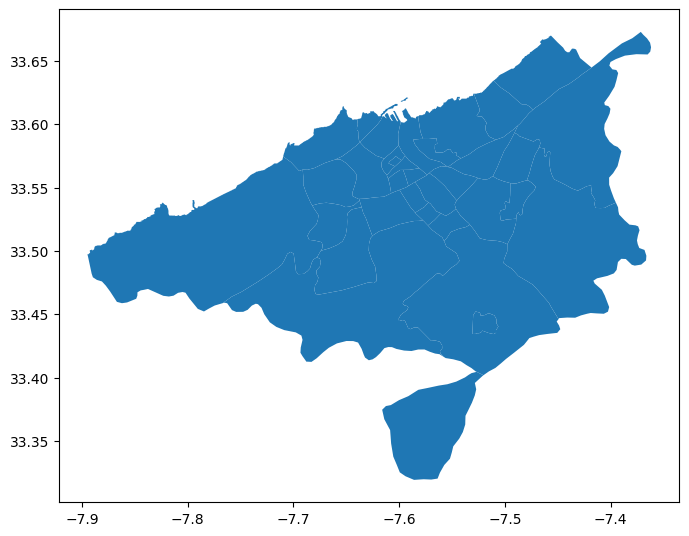

In [68]:
districts_gdf.plot(figsize=(8,8))

In [69]:
# Saving the cleaned districts data as both CSV and GeoPackage files
save_clean_data(districts_gdf, districts_gdf, "Casablanca_Districts")

# Population Data 

In [70]:
# Loading population data for Casablanca districts
population = pd.read_csv(f"{DATA_DIR}/raw/population.csv")
population.head()

,territory_fr,population
0,Commune de Tit Mellil,56019.0
1,Commune de Mediouna,29972.0
2,Commune de Lahraouyine,87977.0
3,Commune de Sidi Hajjaj Oued Hassar,76362.0
4,Commune d'Almajjatia Oulad Taleb,95457.0


In [71]:
# Loading districts data as we will need it to merge with the population data and create a geospatial dataset for population distribution across Casablanca.
districts = gpd.read_file(f"{DATA_DIR}/processed/Casablanca_Districts.gpkg")
communes = districts[["commune", "geometry"]]

To ensure consistency between the naming in poplation and districts dataset, The district and commune names are standardized by removing common prefixes and formatting inconsistencies.

In [72]:
def clean_name(s):
    s = str(s).lower()
    s = s.replace("commune de ", "")
    s = s.replace("arrondissement de ", "")
    s = s.replace("arrondissement d'", "")
    s = s.replace("dont le centre urbain de ", "")
    s = s.replace("-", " ")
    return s.strip()

population["clean_name"] = population["territory_fr"].apply(clean_name)
communes["commune"] = communes["commune"].apply(clean_name)

c:\Users\afafb\AppData\Local\Programs\Python\Python310\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [73]:
population.info(), communes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   territory_fr  27 non-null     object 
 1   population    27 non-null     float64
 2   clean_name    27 non-null     object 
dtypes: float64(1), object(2)
memory usage: 776.0+ bytes
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   commune   34 non-null     object  
 1   geometry  34 non-null     geometry
dtypes: geometry(1), object(1)
memory usage: 672.0+ bytes


(None, None)

This code maps population records to commune names using fuzzy matching. Names are normalized (lowercased, accents removed) before matching. A threshold of 75% similarity is used to determine matches.                            
The results identify matched, unmatched, and communes only present in the GeoDataFrame.

In [74]:
# Function to normalize names: lowercase, remove accents, strip spaces
def normalize(s):
    s = str(s).strip().lower()
    s = unicodedata.normalize("NFD", s)
    s = "".join(c for c in s if unicodedata.category(c) != "Mn")
    return s

# Create a mapping from normalized commune names to original names
arr2_norm = {normalize(c): c for c in communes["commune"]}

mapping_list = []
# Iterate over population DataFrame and perform fuzzy matching to communes
for _, row in population.iterrows(): 
    norm = normalize(row["clean_name"])
    match, score, _ = process.extractOne(norm, list(arr2_norm.keys()), scorer=fuzz.token_sort_ratio)
    mapping_list.append({
        "population_df": row["clean_name"],
        "population":    row["population"], 
        "commune":      arr2_norm[match] if score >= 75 else None,
        "score":         score,
        "status":        "matched" if score >= 75 else "unmatched"
    })

mapping_df = pd.DataFrame(mapping_list)

# Summarize results
matched   = mapping_df[mapping_df.status == "matched"]
unmatched = mapping_df[mapping_df.status == "unmatched"]
in_communes_only = set(communes["commune"]) - set(mapping_df["commune"].dropna())

print(f"Matched:       {len(matched)}")
print(f"Unmatched population_df: {len(unmatched)}")
print(f"Only in communes:  {len(in_communes_only)}")

print("\n--- Unmatched from population_df ---")
print(unmatched[["population_df", "score"]])

print("\n--- Only in communes (no arr1 counterpart) ---")
print(in_communes_only)

Matched:       23
Unmatched population_df: 4
Only in communes:  11

--- Unmatched from population_df ---
             population_df      score
8   commune d'oulad azzouz  41.176471
9    commune d'ouled salah  41.379310
10                victoria  42.105263
17       asoukhour assawda  53.846154

--- Only in communes (no arr1 counterpart) ---
{'assoukhour assawda', 'machouar casablanca', 'sidi maarouf', 'echchallalate', 'bou chentouf', 'ain harrouda', 'ahl laghlam', 'al idrissia', 'moulay youssef', 'lissasfa', 'salmia'}


In [75]:
mapping_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   population_df  27 non-null     object 
 1   population     27 non-null     float64
 2   commune        23 non-null     object 
 3   score          27 non-null     float64
 4   status         27 non-null     object 
dtypes: float64(2), object(3)
memory usage: 1.2+ KB


### Mapping matched communes with geometry

Matched population records are assigned the corresponding commune geometries. A new GeoDataFrame `population_by_districts` is created containing only matched communes with their population and geometry.

In [76]:
# Create a lookup dictionary from commune name to geometry
geometry_lookup = communes.set_index("commune")["geometry"]

# Map the geometries to the population
mapping_df["geometry"] = mapping_df["commune"].map(geometry_lookup)

# Keep only matched records and reset index
population_by_districts = (
    mapping_df[mapping_df.status == "matched"]
    [["commune", "population", "geometry"]]
    .reset_index(drop=True)
)

In [77]:
population_by_districts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   commune     23 non-null     object  
 1   population  23 non-null     float64 
 2   geometry    23 non-null     geometry
dtypes: float64(1), geometry(1), object(1)
memory usage: 680.0+ bytes


### Estimating population at neighborhood level

Population data from HCP is available only at the arrondissement and commune levels. 
However, the analysis requires finer spatial units (neighborhoods).

To address this, we used built-up area information from a raster obtained from Global Human Settlement.  

The process is as follows:
1. Compute the total built-up area within each district polygon.  
2. Use known population values to calculate population density per unit of built-up area.  
3. Estimate population for districts with missing values based on their built-up area and the computed density.  
4. Combine known and estimated populations into a final `population_final` column.

In [78]:
# Keep only communes that are in the population dataset for the next steps of the analysis
in_communes_only = communes[communes["commune"].isin(in_communes_only)]

In [79]:
# Impute population as NaN for communes that are only in the communes dataset and not in the population dataset
in_communes_only['population'] = np.nan

# Append to population_by_districts dataframe 
population_by_districts = pd.concat([population_by_districts, in_communes_only], ignore_index=True)

c:\Users\afafb\AppData\Local\Programs\Python\Python310\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [80]:
# Load Built-up raster (Sentinel-2 2022)
builtup_raster_path = f"{DATA_DIR}/raw/EMC_BUILT_S_E2022_GLOBE_R2025A_4326_3ss_V1_0_R6_C18.tif"

In [81]:
# Function to compute built-up area within a polygon by masking the raster with the polygon geometry and summing the pixel values that represent built-up areas.
def compute_builtup_area(polygon, raster_path):
    """Returns the sum of built-up pixels within a polygon."""
    with rasterio.open(raster_path) as src:
        # Convert polygon to GeoJSON mapping
        geojson_geom = [mapping(polygon)]

        # Clip raster to polygon
        out_image, out_transform = mask(src, geojson_geom, crop=True)
        
        # Flatten array and sum values
        out_image = out_image[0]  # first band
        out_image = np.where(out_image < 0, 0, out_image)  # mask nodata
        builtup_sum = out_image.sum()
    return builtup_sum

In [82]:
# Compute built-up area for each district and add as a new column
population_by_districts['builtup_area'] = population_by_districts.geometry.apply(
    lambda geom: compute_builtup_area(geom, builtup_raster_path)
)

In [83]:
# Separate known and missing population districts
known = population_by_districts.dropna(subset=['population']).copy()
missing = population_by_districts[population_by_districts['population'].isna()].copy()

Compute average population density per unit of built-up area using districts with known population.

In [84]:
# Total population and built-up area
total_pop = known['population'].sum()
total_builtup = known['builtup_area'].sum()

# Compute population density per unit of built-up area
density_per_builtup = total_pop / total_builtup

Estimate population for districts with missing population using their built-up area and the calculated density.

In [85]:
# Create a column for estimated population
population_by_districts['population_estimated'] = None

# fill only missing rows
mask = population_by_districts['population'].isna()

# Fill estimated population for missing rows
population_by_districts.loc[mask, 'population_estimated'] = (
    population_by_districts.loc[mask, 'builtup_area'] * density_per_builtup
)

Combine known and estimated population values into a final column `population_final`.

In [86]:
population_by_districts['population_final'] = population_by_districts['population']

# Fill missing with estimated population
population_by_districts.loc[
    population_by_districts['population_final'].isna(),
    'population_final'
] = population_by_districts.loc[
    population_by_districts['population_final'].isna(),
    'population_estimated'
]

C:\Users\afafb\AppData\Local\Temp\ipykernel_17448\1094619338.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[78216.12432768925 170764.9992650267 30167.74316404813 164028.6799923437
 50184.69369253346 131630.9077522282 14784.452386996802 81127.27285295204
 25189.38513044216 143647.6453067333 216281.67228731883]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  population_by_districts.loc[


In [87]:
population_by_districts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   commune               34 non-null     object  
 1   population            23 non-null     float64 
 2   geometry              34 non-null     geometry
 3   builtup_area          34 non-null     uint32  
 4   population_estimated  11 non-null     object  
 5   population_final      34 non-null     object  
dtypes: float64(1), geometry(1), object(3), uint32(1)
memory usage: 1.6+ KB


We can see that population_final has no missing values, unlike th eoriginal population column

In [88]:
# Rounding final population to nearest integer
population_by_districts['population_final'] = (
    population_by_districts['population_final']
    .round()
    .astype(int)
)

In [89]:
population_by_districts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   commune               34 non-null     object  
 1   population            23 non-null     float64 
 2   geometry              34 non-null     geometry
 3   builtup_area          34 non-null     uint32  
 4   population_estimated  11 non-null     object  
 5   population_final      34 non-null     int32   
dtypes: float64(1), geometry(1), int32(1), object(2), uint32(1)
memory usage: 1.5+ KB


In [90]:
# Keep only relevant columns for the final dataset
population_by_districts = population_by_districts[['commune', 'population_final', 'geometry']]

In [91]:
# Rename population_final to population for clarity in the final dataset
population_by_districts.rename(columns={'population_final': 'population'}, inplace=True)

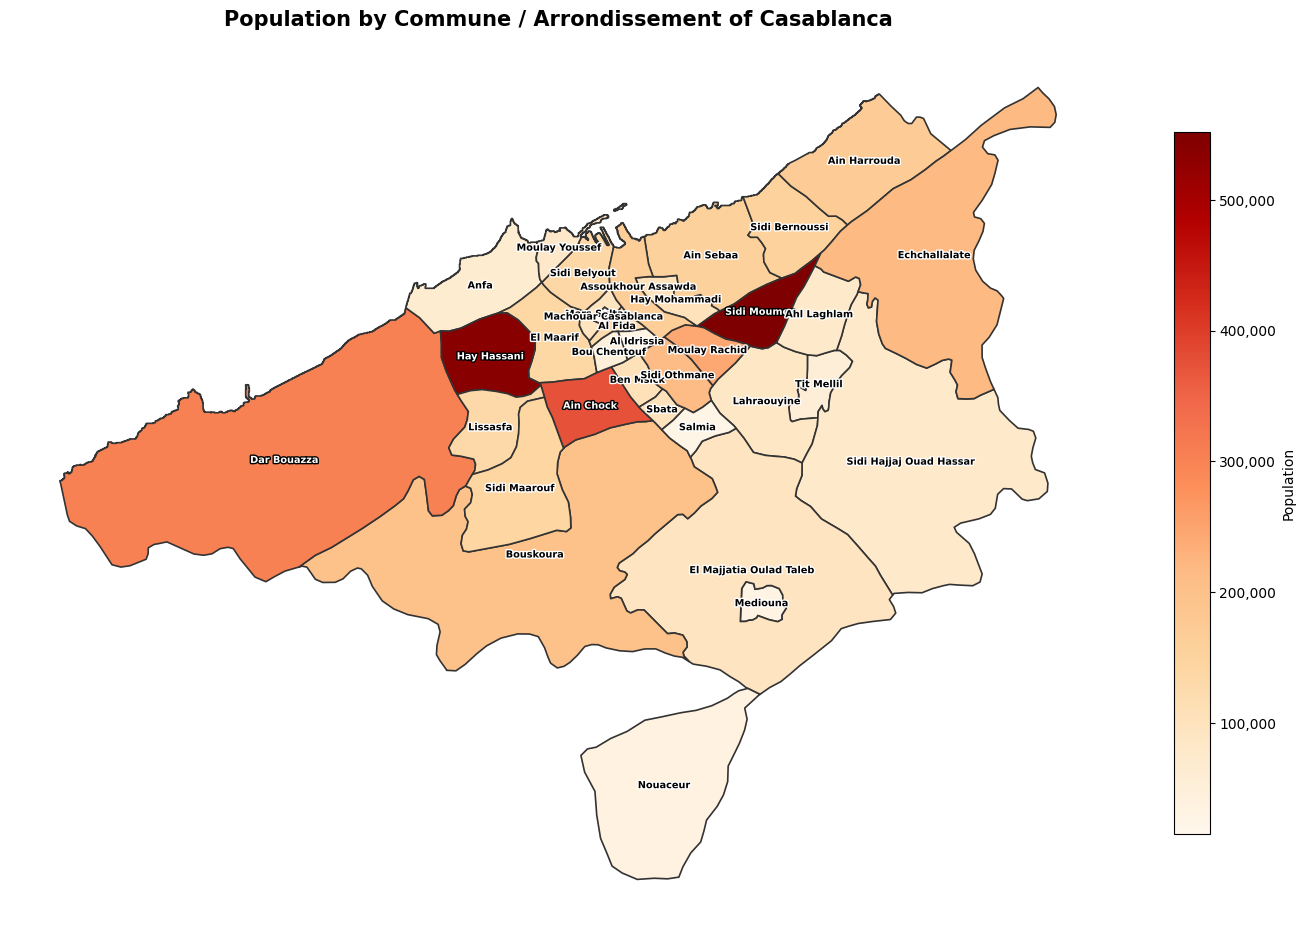

In [92]:
import matplotlib.patheffects as pe
from matplotlib.ticker import FuncFormatter

# make GeoDataFrame 
population_by_districts = gpd.GeoDataFrame(population_by_districts, geometry="geometry") 
population_by_districts = population_by_districts.to_crs(epsg=4326)

fig, ax = plt.subplots(1, 1, figsize=(14, 12)) 

population_by_districts.plot( 
    column="population", 
    cmap="OrRd", 
    linewidth=1.2,          # slightly thicker borders
    edgecolor="#333333",    # softer than pure black
    legend=True,
    legend_kwds={
        "label": "Population",
        "orientation": "vertical",
        "shrink": 0.6,
        "format": FuncFormatter(lambda x, _: f"{int(x):,}")  # comma-formatted ticks
    },
    ax=ax 
) 

for idx, row in population_by_districts.iterrows():
    pop = row["population"]
    name = row["commune"].title()  # capitalize each word

    # pick label color based on background darkness
    text_color = "white" if pop > 300_000 else "black"

    ax.annotate(
        name,
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        horizontalalignment='center',
        verticalalignment='center',
        fontsize=7,
        color=text_color,
        fontweight='bold',
        path_effects=[                          # white halo for contrast
            pe.withStroke(linewidth=2, foreground="white" if text_color == "black" else "black")
        ]
    )

ax.set_title(
    "Population by Commune / Arrondissement of Casablanca",
    fontsize=15,
    fontweight='bold',
    pad=16
)
ax.axis("off")

plt.tight_layout()
plt.savefig(f"{DATA_DIR}/processed/population_by_districts.png", dpi=300, bbox_inches='tight')
plt.show()

In [93]:
# Save final results
save_clean_data(population_by_districts, population_by_districts, "population_by_districts")